In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile
import matplotlib.pyplot as plt
from mido import MidiFile
from scipy.fft import fft

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 292 midi files.


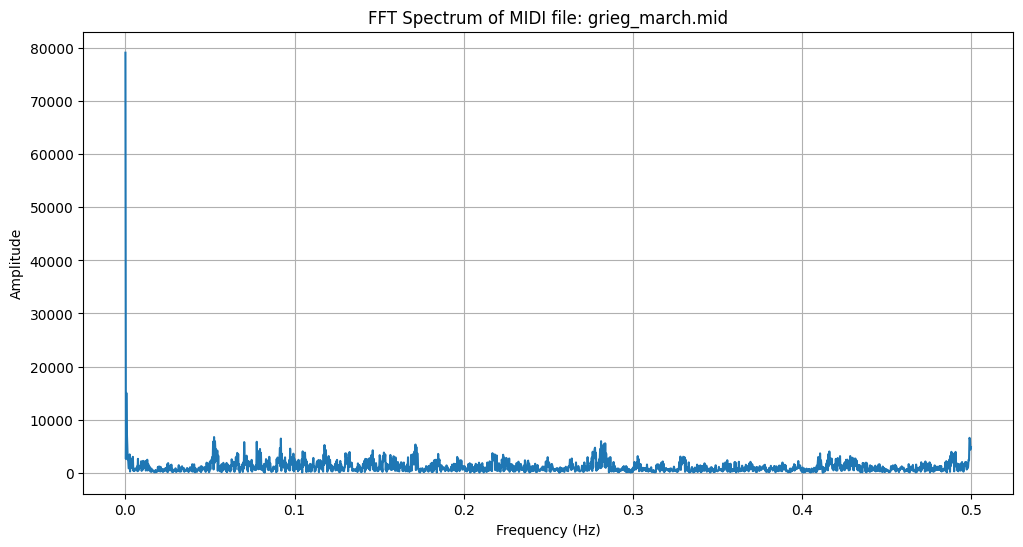

In [ ]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
from mido import MidiFile

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Đường dẫn thư mục chứa file .mid
folder_path = '/content/drive/MyDrive/Time_series/Thuc_hanh4'

# 3. Hàm đọc dữ liệu MIDI và chuyển sang dạng dữ liệu thời gian hoặc velocity để phân tích FFT
def extract_signal_from_midi(mid_file):
    mid = MidiFile(mid_file)
    # Chúng ta sẽ lấy velocity của các note on theo thời gian
    velocities = []
    times = []
    current_time = 0
    for msg in mid:
        current_time += msg.time
        if not msg.is_meta and msg.type == 'note_on':
            velocities.append(msg.velocity)
            times.append(current_time)
    # Chuyển list velocities thành numpy array
    signal = np.array(velocities)
    return signal

# 4. Hàm tính FFT và trả về tần số và biên độ phổ
def compute_fft(signal, sample_rate=1):
    # sample_rate = 1 vì ta không có sampling rate chính xác, giả định 1 unit thời gian cho mỗi step
    n = len(signal)
    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(n, d=1/sample_rate)
    # Chỉ lấy phần dương của tần số
    pos_mask = fft_freq >= 0
    return fft_freq[pos_mask], np.abs(fft_vals[pos_mask])

# 5. Lấy file ví dụ và vẽ phổ FFT
midi_files = [f for f in os.listdir(folder_path) if f.endswith('.mid')]
print(f"Found {len(midi_files)} midi files.")

if midi_files:
    example_file = os.path.join(folder_path, midi_files[0])
    signal = extract_signal_from_midi(example_file)
    freqs, amps = compute_fft(signal)

    plt.figure(figsize=(12,6))
    plt.plot(freqs, amps)
    plt.title(f'FFT Spectrum of MIDI file: {midi_files[0]}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()
else:
    print("No midi files found in the folder.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã tìm thấy 292 file MIDI.


<ipython-input-8-9afa798e4720>:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


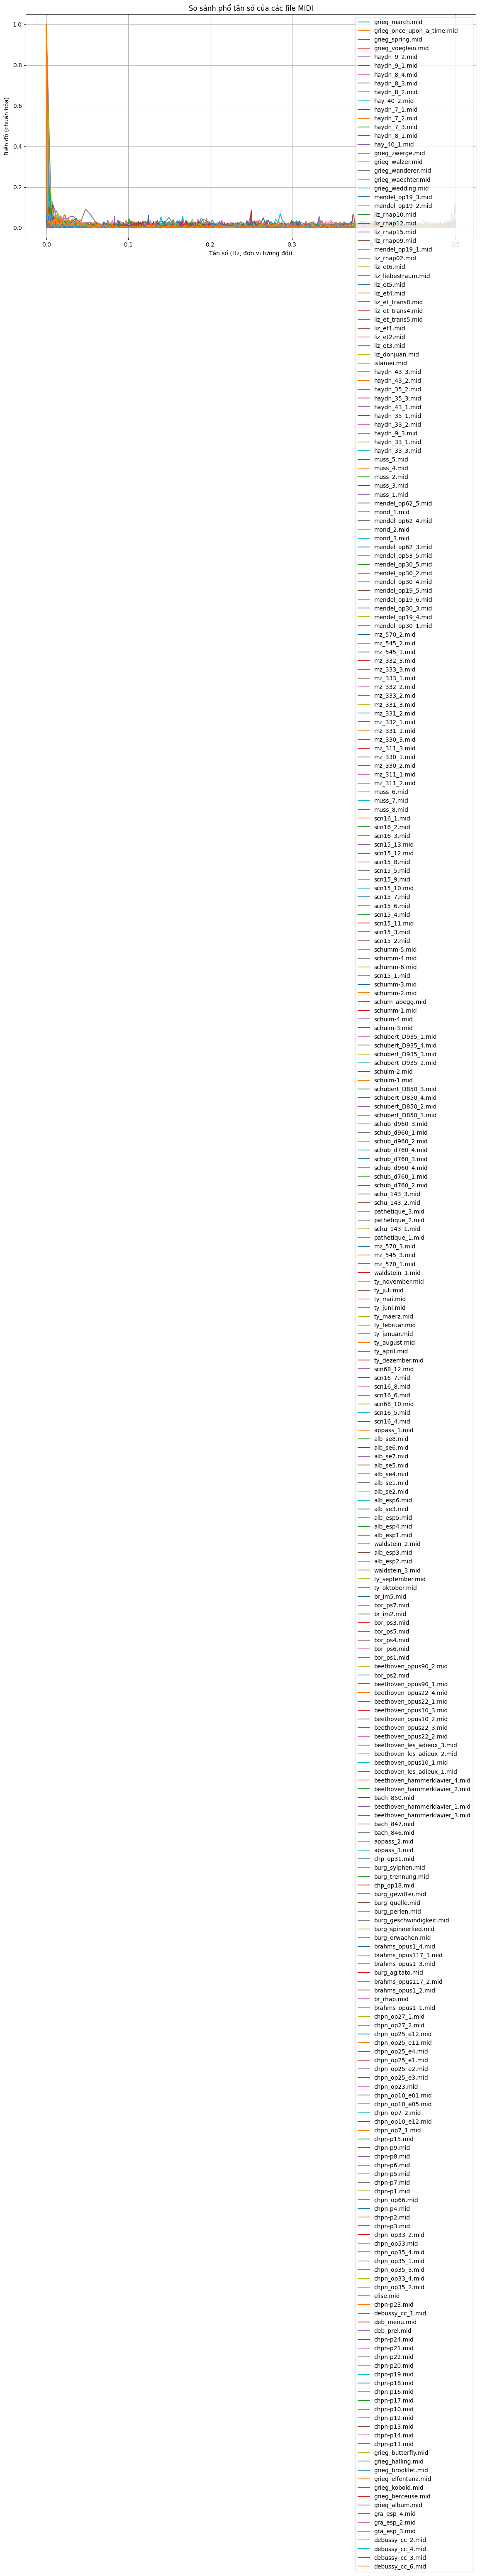

In [ ]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
from mido import MidiFile

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Đường dẫn thư mục chứa file MIDI
folder_path = '/content/drive/MyDrive/Time_series/Thuc_hanh4'

# 3. Hàm trích xuất velocity từ MIDI
def extract_signal_from_midi(mid_file):
    mid = MidiFile(mid_file)
    velocities = []
    for msg in mid:
        if not msg.is_meta and msg.type == 'note_on' and msg.velocity > 0:
            velocities.append(msg.velocity)
    return np.array(velocities)

# 4. Hàm tính FFT
def compute_fft(signal):
    n = len(signal)
    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(n, d=1)  # đơn vị thời gian giả định = 1
    pos_mask = fft_freq >= 0
    return fft_freq[pos_mask], np.abs(fft_vals[pos_mask])

# 5. Đọc tất cả file MIDI
midi_files = [f for f in os.listdir(folder_path) if f.endswith('.mid')]
print(f"Đã tìm thấy {len(midi_files)} file MIDI.")

# 6. Tính FFT cho từng file và lưu kết quả
fft_results = {}

for midi_file in midi_files:
    file_path = os.path.join(folder_path, midi_file)
    signal = extract_signal_from_midi(file_path)

    if len(signal) < 2:
        print(f"Bỏ qua {midi_file} vì tín hiệu quá ngắn.")
        continue

    freqs, amps = compute_fft(signal)
    fft_results[midi_file] = (freqs, amps)

# 7. Trực quan hóa so sánh các phổ FFT
plt.figure(figsize=(14, 7))
for name, (freqs, amps) in fft_results.items():
    # Chuẩn hóa biên độ để so sánh
    amps_norm = amps / np.max(amps)
    plt.plot(freqs, amps_norm, label=name)

plt.title('So sánh phổ tần số của các file MIDI')
plt.xlabel('Tần số (Hz, đơn vị tương đối)')
plt.ylabel('Biên độ (chuẩn hóa)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
import os
import numpy as np
from mido import MidiFile
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import re

# Mount Google Drive
drive.mount('/content/drive')

# Thư mục chứa file MIDI
folder_path = '/content/drive/MyDrive/Time_series/Thuc_hanh4'

# Trích xuất nhãn thể loại từ tên file
def get_genre_from_filename(filename):
    return filename.split('_')[0].lower()

# Hàm trích xuất đặc trưng cơ bản từ MIDI
def extract_features(mid_file):
    mid = MidiFile(mid_file)
    tempos = []
    note_counts = 0
    note_on_velocities = []
    note_lengths = []

    current_time = 0
    active_notes = {}

    for msg in mid:
        current_time += msg.time
        if msg.is_meta and msg.type == 'set_tempo':
            tempos.append(msg.tempo)
        elif not msg.is_meta:
            if msg.type == 'note_on' and msg.velocity > 0:
                note_on_velocities.append(msg.velocity)
                active_notes[msg.note] = current_time
                note_counts += 1
            elif (msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0)) and msg.note in active_notes:
                duration = current_time - active_notes[msg.note]
                note_lengths.append(duration)
                del active_notes[msg.note]

    avg_velocity = np.mean(note_on_velocities) if note_on_velocities else 0
    std_velocity = np.std(note_on_velocities) if note_on_velocities else 0
    avg_duration = np.mean(note_lengths) if note_lengths else 0
    std_duration = np.std(note_lengths) if note_lengths else 0
    avg_tempo = np.mean(tempos) if tempos else 500000  # default tempo

    # Feature vector
    return [
        note_counts,
        avg_velocity,
        std_velocity,
        avg_duration,
        std_duration,
        avg_tempo
    ]

# Load dữ liệu
X = []
y = []

for fname in os.listdir(folder_path):
    if fname.endswith('.mid'):
        try:
            fpath = os.path.join(folder_path, fname)
            features = extract_features(fpath)
            genre = get_genre_from_filename(fname)
            X.append(features)
            y.append(genre)
        except Exception as e:
            print(f"Lỗi xử lý {fname}: {e}")

# Huấn luyện mô hình
X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Kết quả
print("=== Kết quả phân loại ===")
print(classification_report(y_test, y_pred))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Kết quả phân loại ===
              precision    recall  f1-score   support

         alb       0.50      0.25      0.33         4
        bach       0.00      0.00      0.00         0
   beethoven       0.00      0.00      0.00         1
         bor       0.00      0.00      0.00         2
      brahms       1.00      0.50      0.67         2
        burg       0.00      0.00      0.00         0
         chp       0.00      0.00      0.00         1
        chpn       0.00      0.00      0.00         2
chpn-p12.mid       0.00      0.00      0.00         1
chpn-p13.mid       0.00      0.00      0.00         1
chpn-p14.mid       0.00      0.00      0.00         1
chpn-p16.mid       0.00      0.00      0.00         1
chpn-p19.mid       0.00      0.00      0.00         1
chpn-p24.mid       0.00      0.00      0.00         0
 chpn-p5.mid       0.00      0.00 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_